
### Part 1: Reimplement Continuous VAE

- Implement a continuous VAE on the CIFAR10 dataset
- Construct fully connected and convolutional versions


### Part 2: Discrete VAE

- Implement a discrete VAE on the CIFAR10 dataset; you may use either a fully connected or convolutional architecture


### Part 3: "YOLOv0"

- Implement a YOLO-like model for object detection using the Pascal VOC 2012 dataset
- Detect objects across a 7x7 grid using a convolutional architecture
- Simplifications: Just a single bounding box allowed in each grid-cell
- Also use cross-entropy loss for object class, and use a simple objectness score vs. the confidence score in YOLO

In [1]:
%pip install pandas matplotlib torchvision torch datasets

In [2]:
# Some libraries you'll likely need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#PyTorch Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

import torchvision.transforms.v2 as transforms

from torch.utils.data import Dataset, DataLoader


## Part 1: Continuous VAEs

Your tasks here:

### A. Get the data

1. Get the CIFAR10 dataset from torchvision
2. Plot some examples
3. Appropriately wrap into a dataloader (you may divide into train and validation sets/loaders if you like, to confirm that the model reconstructs validation inputs well)


### B. VAE, FC architecture

1. Implement a continuous VAE: You are advised to follow our work in class and the posted notebook
    - This VAE should use simple fully connected layers in the encoder and decoder. The exact details are up to you, but at least alter the architecture slightly from what was provided in class.
2. Train: Train using an appropriate training loop, etc., and using both reconstruction and latent losses
3. Visually assess the ability of the model to reconstruct input images on a few sample images
4. Create some examples of generated images sampling from the latent space (sample from a standard normal)


### C. VAE, Convolutional architecture

1. Repeat the same basic steps as in Part B, but use the convolutional architecture of your choice (I suggest keeping it relatively simple, and again, please alter at least nominally from the lecture example)


### Ignore

In [ ]:
nn.Conv2d?

Init signature:
nn.Conv2d(
    in_channels: int,
    out_channels: int,
    kernel_size: int | tuple[int, int],
    stride: int | tuple[int, int] = 1,
    padding: str | int | tuple[int, int] = 0,
    dilation: int | tuple[int, int] = 1,
    groups: int = 1,
    bias: bool = True,
    padding_mode: Literal['zeros', 'reflect', 'replicate', 'circular'] = 'zeros',
    device=None,
    dtype=None,
) -> None
Docstring:     
Applies a 2D convolution over an input signal composed of several input
planes.

In the simplest case, the output value of the layer with input size
:math:`(N, C_{\text{in}}, H, W)` and output :math:`(N, C_{\text{out}}, H_{\text{out}}, W_{\text{out}})`
can be precisely described as:

.. math::
    \text{out}(N_i, C_{\text{out}_j}) = \text{bias}(C_{\text{out}_j}) +
    \sum_{k = 0}^{C_{\text{in}} - 1} \text{weight}(C_{\text{out}_j}, k) \star \text{input}(N_i, k)


where :math:`\star` is the valid 2D `cross-correlation`_ operator,
:math:`N` is a batch size, :math:`C` denot

In [ ]:
torch.nn.Module?

Init signature: torch.nn.Module(*args: Any, **kwargs: Any) -> None
Docstring:     
Base class for all neural network modules.

Your models should also subclass this class.

Modules can also contain other Modules, allowing them to be nested in
a tree structure. You can assign the submodules as regular attributes::

    import torch.nn as nn
    import torch.nn.functional as F


    class Model(nn.Module):
        def __init__(self) -> None:
            super().__init__()
            self.conv1 = nn.Conv2d(1, 20, 5)
            self.conv2 = nn.Conv2d(20, 20, 5)

        def forward(self, x):
            x = F.relu(self.conv1(x))
            return F.relu(self.conv2(x))

Submodules assigned in this way will be registered, and will also have their
parameters converted when you call :meth:`to`, etc.

.. note::
    As per the example above, an ``__init__()`` call to the parent class
    must be made before assignment on the child.

:ivar training: Boolean represents whether this module is in

In [ ]:
# class ConvEncoder(nn.Module):
#     def __init__(self, in_channels, out_channels,kernel_size,stride, padding, pool_kernel_size, num_of_layers):
#         assert num_of_layers >= 1, "num_of_layers must be >= 1"

#         super().__init__()
#         self.layers = nn.ModuleList()
#         self.out_channels = out_channels
#         base = out_channels // (2 ** (num_of_layers - 1)) # factor of 2
#         curr_in = in_channels
#         for i in range(num_of_layers):
#             layer_out = base * (2 ** i) # assuming the layers in constructor is factor fof 2
#             self.layers.append(nn.Sequential(
#                 nn.Conv2d(curr_in, layer_out, kernel_size, stride, padding),
#                 # same padding is better for full spatial info
#                 nn.BatchNorm2d(layer_out),
#                 nn.MaxPool2d(pool_kernel_size),
#                 nn.ReLU()
#             ))
#             curr_in = layer_out
#         # 3*3*64 -> bottleneck layer for getting latent info
#         self.linear_end = nn.Linear(3 * 3 * out_channels, out_channels)

#     def forward(self, x):
#         for layer in self.layers:
#             x = layer(x)

#         x = x.view(-1, 3*3* (self.out_channels)) # reshape for final layer of encoder
#         x = self.linear_end(x)

#         return x



In [ ]:
class ConvEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, (3,3), stride=1, padding='same')
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, (3,3), stride=1, padding='same')
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(32, 64, (3,3), stride=1, padding='same')
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.linear = nn.Linear(4*4*64, 64)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 4*4*64)
        x = self.linear(x)
        return x

In [ ]:
# conv_encoder = ConvEncoder(3, 64, (2,2), 1, 'same', (2,2), 3)
# Encoder used padding='same' so convs keep spatial size and MaxPool halves it predictably.


In [ ]:
conv_encoder = ConvEncoder()


In [ ]:
# conv_encoder.layers

In [ ]:
# class ConvDecoder(nn.Module):
#     def __init__(self, in_channels, out_channels,kernel_size,stride, padding, output_padding, num_of_layers):
#         assert num_of_layers >= 1, "num_of_layers must be >= 1"

#         super().__init__()
#         self.layers = nn.ModuleList()
#         self.in_channels = in_channels
#         base = in_channels // (2 ** (num_of_layers - 1))
#         print(base)
#         curr_in = in_channels
#         for i in range(num_of_layers):
#             layer_out = base * (2 ** i)

#             # first layer may need different padding/output_padding to get desired sizes
#             if i == 0:
#                 conv = nn.ConvTranspose2d(curr_in, layer_out, kernel_size, stride, padding=0, output_padding=0)
#                 act = nn.ReLU()
#             # last layer produces final channels and squash to [0,1]
#             elif i == (num_of_layers - 1):
#                 conv = nn.ConvTranspose2d(curr_in, layer_out, kernel_size, stride, padding=padding, output_padding=output_padding)
#                 act = nn.Sigmoid()
#             else:
#                 conv = nn.ConvTranspose2d(curr_in, layer_out, kernel_size, stride, padding=padding, output_padding=output_padding)
#                 act = nn.ReLU()

#             self.layers.append(nn.Sequential(
#                 conv,
#                 nn.BatchNorm2d(layer_out),
#                 act
#             ))
#             curr_in = layer_out


#         # so that we bound the final output within the rarnge of 0, 1 while not in encoder because we want true latent representation
#         self.linear_start= nn.Linear(in_channels, 3*3*in_channels)


#     def forward(self, x):
#         x = self.linear_start(x).view(-1, self.in_channels, 3,3)
#         for layer in self.layers:
#             x = layer(x)
#         return x



In [ ]:
# conv_decoder = ConvDecoder(64, 1, (3,3), 2, 1, 1,3)

In [ ]:
# conv_decoder.layers

In [ ]:
class ConvDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer0 = nn.Linear(64, 4*4*64)

        self.convT1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.convT2 = nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(16)

        self.convT3 = nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(3)

        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

    def forward(self, x):
        x = (self.layer0(x)).view(-1, 64, 4, 4)

        x = self.relu(self.bn1(self.convT1(x)))
        x = self.relu(self.bn2(self.convT2(x)))
        x = self.sigmoid(self.bn3(self.convT3(x)))
        return x



In [ ]:
conv_decoder = ConvDecoder()

In [ ]:
conv_decoder = ConvDecoder()
conv_autoencoder = nn.Sequential(conv_encoder, conv_decoder)

device = "cuda" if torch.cuda.is_available() else "cpu"
conv_autoencoder = conv_autoencoder.to(device)

In [ ]:
conv_autoencoder

Sequential(
  (0): ConvEncoder(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (linear): Linear(in_features=1024, out_features=64, bias=True)
    (relu): ReLU()
  )
  (1): ConvDecoder(
    (layer0): Linear(in_features=64, out_features=1024, bias=True)
    (convT1): ConvTransp

In [ ]:
# loss_fn = nn.MSELoss()
# optimizer = torch.optim.Adam(conv_autoencoder.parameters(), lr=0.005)

# losses=[]

# for epoch in range(1):
#     conv_autoencoder.train()
#     for batch in train_loader:
#         optimizer.zero_grad()
#         X_in,y = batch
#         X_in = X_in.to(device)
#         y= y.to(device)


#         X_out = conv_autoencoder(X_in)

#         loss = loss_fn(X_out, X_in)

#         loss.backward()

#         optimizer.step()

#         losses.append(loss.item())

#     print(f"Epoch : {epoch}, loss : {losses}")


## Answers

<img src="./vae/vae.excalidraw.png"/>

### A Get the data

In [3]:
## Off you go!
from torchvision.transforms import ToTensor
from torch.utils.data import Subset

# loading the cifar dataset from torchvision
cifar_trainset = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=ToTensor())
cifar_testset = torchvision.datasets.CIFAR10(root='./data', train=False,download=True, transform=ToTensor())

# using subset of the dataset
indices1 = range(0, int(55e3), 1)
indices2 = range(int(55e3), int(60e3), 1)

cifar_train = Subset(cifar_trainset, indices1 )
cifar_test = Subset(cifar_testset, indices2 )

# prepare train loader
train_loader = DataLoader(cifar_trainset, batch_size=32, shuffle=True)
test_loader = DataLoader(cifar_testset, batch_size=32, shuffle=True)



100%|██████████| 170M/170M [00:02<00:00, 79.8MB/s] 


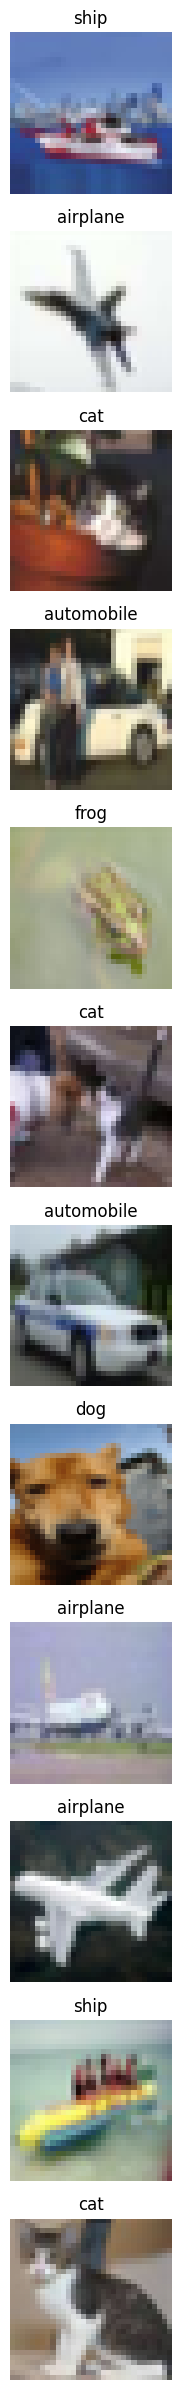

In [4]:
# prepare plot
from torchvision.utils import make_grid

imgs,labels = next(iter(train_loader))
# imgs,labels = next(iter(test_loader))
len(imgs)
len(labels)

n=12

fig, axes = plt.subplots(n, 1, figsize=(4, 2*n))
for i in range(n):
    ax = axes[i]
    img = imgs[i].permute(1,2,0).numpy()
    ax.imshow(img)
    ax.set_title(cifar_trainset.classes[labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()


### B VAE FC Architecture

#### Encoder  

- this will get input matrice
- pass through first linear layer on relu
- go through a linear layer with double dimension (mean, log_var) 

In [144]:
class FC_VAE_Encoder(nn.Module):
    # 1. get input
    # 2. apply relu
    # in last layer, dont apply relu, output in double dimension for mu and log var
    def __init__(self, input_dim, latent_dim ):
        assert input_dim > 0, "input_dim must be positive"
        assert latent_dim > 0, "latent_dim must be positive"

        super().__init__()

        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2 * latent_dim) # we make it produce,

        self.relu = nn.ReLU()



    def forward(self,x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        # we won't do relu on fc3 because we want raw parameters of the latent distribution that is [mu, logvar]
        # mean is the exact center of the target.
        # std is how wide the target area is.
        x = self.fc3(x)
        return x







#### Decoder 
- this will get information rich latent vector
- pass it through again two linear layers on relu
- return final layer iwht outputdim 

In [ ]:
class FC_VAE_Decoder(nn.Module):
    # 1. get input from reparameterized info rich latent vector
    # 2. apply relu
    # 3. no relu in last layer because we want the real reconstruction that has negative values so we efficiently compute the loss in future
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        assert output_dim > 0, "output_dim must be positive"
        assert latent_dim > 0, "latent_dim must be positive"


        self.fc1 = nn.Linear(latent_dim, 64)
        self.fc2 = nn.Linear(64, 128) # reconstruction loss begins here
        self.fc3 = nn.Linear(128, output_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        x = self.sigmoid(x) # to prevent gradient explosion

        return x

#### VAE

- get intput
- flatten it
- pass it through encoder 
- get output from encoder, call reparameterize function for getting the joint mu and log var
- chunk mu and log var separately, apply reparameterization technique $z = \mu + \epsilon * \sigma $
- get the latent vector
- pass it through decoder 
- get decoder output

In [199]:
class FC_VAE(nn.Module):
    # 1. get input and pass it to encoder
    # 2. get mu and logvar from encoder
    # 3. apply reparameterize trick and compute cloud latent rich single point vector
    #   a. generate a random epsilon with the same sized matrice of mean
    #   b. compute standard deviation by using logvar vector
    #   c. compute the latent vector by summing mean and epsilon*std
    # 4. pass it to decoder
    # 5. return mu gamma and decoder output
    def __init__(self, input_dim, latent_dim):
        assert input_dim > 0, "input_dim must be positive"
        assert latent_dim > 0, "latent_dim must be positive"

        super().__init__()
        self.encoder = FC_VAE_Encoder(input_dim,latent_dim)
        self.decoder = FC_VAE_Decoder(latent_dim, input_dim) # we are making big to small -> bottleneck -> back to big

    def reparameterize(self, mu, log_var):
        assert mu.shape == log_var.shape, "mu and log_var must have the same shape"

        # instead of applying loss to randomized samples, we add epsilon to std instead for the random factor
        epsilon = torch.randn_like(mu) # random matrice of shape mean
        std = torch.exp(.5 * log_var)
        z = mu + epsilon*std
        return z

    def forward(self, x):
        assert x.dim() == 2, "Input x must be (batch, features)"

        mu_log_var = self.encoder(x)
        mu, log_var = mu_log_var.chunk(2, axis=-1)
        z = self.reparameterize(mu,log_var)
        recon = self.decoder(z)
        assert recon.shape == x.shape, "Reconstructed output must have the same shape as input"
        return recon, mu, log_var




#### Training loop

<a id="kl_divergence"></a>

**KL Divergence equation :**


$$KL = -0.5 \cdot \sum \left(1 + \log(\sigma^2) - \mu^2 - \sigma^2\right)$$




where -0.5 comes from gaussian distribution integral for balancing the inf equation
$\log(\sigma)$ is the radius of the point or the "region"

$\mu$ is the distance from center of latent vector generated and center of map

$\sigma$ is the radius of the cloud generated

we take log of sigma as well as sigma square so that we can penalize if model memmorizes to just focus on getting std to 0 so it just becomes one perfect point, thats why we have log sigma so that log of 0 becomes inf negative

and then if it takes std and make a really big curve of cloud, then we have -sig^2 so that it penalizes

the main issue i encountered was using mse loss with "mean"' instead of sum, fixing that really helped the model in better accounting the loss, since reconstruction loss is calculated over 3,072 pixels (for a 32×32×3 CIFAR image).
but KL Divergence is calculated over our 64 latent dimensions so taking mean of both of these here will cause kl divergence to dominate and recon error to look very very tiny, 
and then The optimizer sees a "huge" KL penalty and a "tiny" reconstruction penalty so it decides inorder to lower loss, make the KL loss zero. It does this by collapsing the latent space (setting μ=0 and σ=1), effectively turning the encoder off. The model results in ignoring the input image entirely which is why i was getting so blurry images.

By switching to sum, the error from 3,072 pixels carries 3,072 times more weight than a single pixel, which is necessary to force the model to actually care about the fine details of the CIFAR images  

also, clamping the logvar  will prevent numerical instability, i was getting lot of NaNs, clamping keeps the exponential and log functions from hitting infinity or zero.

In [ ]:
imgs, label = next(iter(train_loader))
b, c, h, w = imgs.shape
# input_dim_flat = c * h * w
input_dim_flat = imgs.view(b, -1).shape[1]
latent_dim = 64

input_dim = input_dim_flat
input_dim

3072

In [ ]:
torch.flatten(imgs[0]).shape

torch.Size([3072])

In [ ]:
imgs[0].flatten(0).shape

torch.Size([3072])

In [ ]:
labels

tensor([8, 2, 7, 1, 7, 6, 3, 5, 9, 7, 0, 0, 7, 9, 6, 2, 2, 5, 0, 1, 9, 3, 1, 0,
        2, 0, 9, 1, 2, 7, 6, 6])

In [ ]:
cifar_trainset.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [ ]:
model = FC_VAE(input_dim,latent_dim)

In [ ]:
loss_fn = nn.MSELoss(reduction="sum") # we use sum becaseu KL loss is based on probability distribution
optimizer = torch.optim.Adam(params= model.parameters(),lr=0.0001)

In [ ]:
epochs = 50

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [216]:
model.train()
# 1. loop through epochs
# 2. loop through the trainloader
# 3. get the batch img and flatten it
# 4. pass it through encoder and decoders to get x and mu, logvar
# 5. compute loss
# 6. backpropagate and update weights

for epoch in range(epochs):
    total_loss = []
    _recon_loss = []
    _kl_loss=[]
    
    for imgs, _ in train_loader:
        imgs = imgs.to(device)

        # we flatten our input since we have made linear layer to directly accept 3072 as the dim
        inputs = imgs.flatten(1)

        recon, mean, log_var = model(inputs)
        assert not (recon.isnan().any() or mean.isnan().any() or log_var.isnan().any()), "Nan found!"
        
        log_var = torch.clamp(log_var, min=-10, max=10)


        # loss calculation
        # 1. mean here is the center point of the counstruction, the more it is, the farther the image has drifted away from center point
        # 2. log_var here is the log-variance from encoder output
        # 3. add 1 to the equation so it tells the model when to stop and the loss is perfect
        # 4. we add -0.5 so that the KL doesnt become too strong mathematically
        # 5. we add those up the penalties for every single dimension in latent space and every image in the batch to get one single number for the optimizer to minimize.
        K_loss = -0.5 * torch.sum(1 + log_var - mean.pow(2) - torch.exp(log_var), dim=1).mean()


        # beta = 0.1
        beta = 0.1
        # beta < 1 -> vae uses entangled latent vectors, to generate sharper images as an accurate replica of the input, example : compression
        # if beta is > 1 -> vae uses independent latent vectors and understsand true deep meaning, at the cost of blurrier image, for example, just changing a smile of a person's face without changing entire image layout, a pure refine detailed change.  example : generative ai images, note here: vae's dont generate images, GANs use vaes with high beta to understand latent representataion and then they use it to generate images.

        recon_loss = loss_fn(recon, inputs)
        
        loss = recon_loss + K_loss * beta

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss.append(loss.item())
        _kl_loss.append(K_loss)
        _recon_loss.append(recon_loss)


    print(f"Epoch : {epoch}, Mean Loss : {sum(total_loss)/len(total_loss)}, KL Loss : {sum(_kl_loss)/len(_kl_loss)}, Recon Loss : {sum(_recon_loss)/len(_recon_loss)}")


Epoch : 0, Mean Loss : 1246.452687288505, KL Loss : 137.825927734375, Recon Loss : 1232.6710205078125
Epoch : 1, Mean Loss : 1244.4800334205554, KL Loss : 135.49081420898438, Recon Loss : 1230.9312744140625
Epoch : 2, Mean Loss : 1244.0016732145714, KL Loss : 135.1200408935547, Recon Loss : 1230.488037109375
Epoch : 3, Mean Loss : 1243.680869114071, KL Loss : 134.93162536621094, Recon Loss : 1230.187744140625
Epoch : 4, Mean Loss : 1243.3975933560635, KL Loss : 134.62173461914062, Recon Loss : 1229.9354248046875
Epoch : 5, Mean Loss : 1243.342041328025, KL Loss : 134.41912841796875, Recon Loss : 1229.90087890625
Epoch : 6, Mean Loss : 1243.205887475383, KL Loss : 134.2833251953125, Recon Loss : 1229.7763671875
Epoch : 7, Mean Loss : 1243.0825456166526, KL Loss : 134.02407836914062, Recon Loss : 1229.6800537109375
Epoch : 8, Mean Loss : 1242.9492306602513, KL Loss : 133.86666870117188, Recon Loss : 1229.5628662109375
Epoch : 9, Mean Loss : 1242.9139714744406, KL Loss : 133.8718872070312

In [219]:
# torch.save(model.state_dict(), "fcvae.pt")
torch.save(model.state_dict(), "fcvae2.pt")

#### Eval

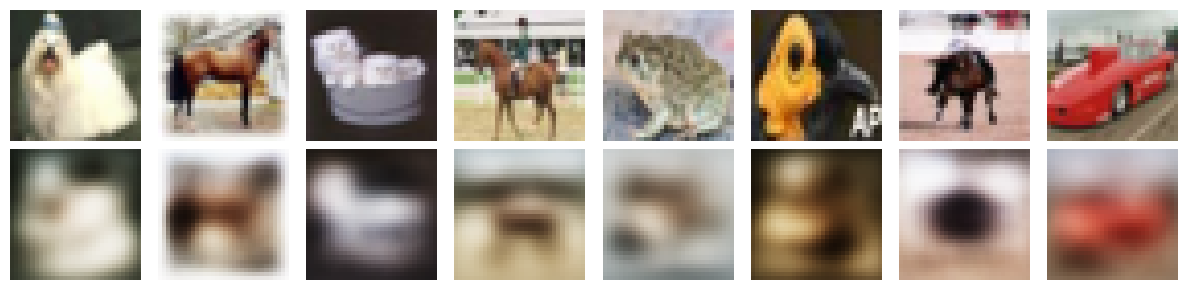

In [218]:

model.eval()

with torch.no_grad():
    test_data = next(iter(test_loader))[0][:8].to(device)
    test_data = test_data.flatten(1)
    recon, _, _ = model(test_data)

# generated by claude
# ---
fig, axes = plt.subplots(2, 8, figsize=(12, 3))

for i in range(8):
    # Original image
    orig_img = test_data[i].cpu().reshape(3, 32, 32).permute(1, 2, 0)
    axes[0, i].imshow(orig_img, cmap='gray_r')
    axes[0, i].axis('off')
    # Reconstructed image
    recon_img = recon[i].cpu().reshape(3, 32, 32).permute(1, 2, 0)
    axes[1, i].imshow(recon_img, cmap='gray_r')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', size=12)
axes[1, 0].set_ylabel('Reconstructed', size=12)
plt.tight_layout()
# plt.savefig('v1_vae.png')
plt.savefig('v2_vae.png')
# ---

### C VAE Conv Architecture

#### Encoder

- get raw input without flattening
- pass through conv layers 
- apply pooling for feature extraction
- flatten the image to latent dim

In [45]:
class Conv_VAE_Encoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        # 32x32
        self.layers = nn.Sequential(
            # 16x16
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 8x8
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 4x4
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        # After 3 pooling: 32 -> 16 -> 8 -> 4, channels 64
        self.fc_mu_logvar = nn.Linear(64 * 4 * 4, 2 * latent_dim)
        self.relu = nn.ReLU()

    
    def forward(self, x):
        # print(x.shape)
        x = self.layers(x)
        
        x = x.view(x.size(0), -1) 
        x = self.fc_mu_logvar(x)
        
        return x 

#### Decoder

- get latent flatten linear input from encoder
- upsample spatial dims and shrink channels
- return final recon



In [46]:
class Conv_VAE_Decoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64*4*4)
        # 4x4
        # kernel size increases size, stride decreases it, padding increases
        # 8x8
        # self.conv1 = nn.Conv2d(64, 32, kernel_size=4, stride=2, padding=1)
        # regular conv stride 2 shrinks spatial dimensions, we want to upsample noto shrink
        self.conv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # 16x16
        self.conv2 = nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        
        # 32x32
        self.conv3 = nn.ConvTranspose2d(16,3, kernel_size=4, stride=2, padding=1)
        
        self.relu= nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self,x):
        x = self.fc(x).view(-1, 64, 4, 4)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.sigmoid(self.conv3(x))
        return x


#### VAE

- initiate encoder decoder
- pass through encoder
- get mulogvar
- apply reparametrization trick
- pass to decoder
- return output

In [47]:
class Conv_VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = Conv_VAE_Encoder(latent_dim)
        self.decoder = Conv_VAE_Decoder(latent_dim)
        
    def reparameterize(self, mu,log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(mu)
        z = mu + eps * std
        return z
    
    def forward(self,x):
        mulogvar = self.encoder(x)
        mu, log_var = mulogvar.chunk(2,dim=-1)
        z = self.reparameterize(mu,log_var)
        recon = self.decoder(z)
        return recon,mu,log_var
        
        

#### Training

In [50]:
model = Conv_VAE(latent_dim=64)
epochs=100
device = 'cuda' if torch.cuda.is_available() else "cpu"
model.to(device)  
loss_fn = nn.MSELoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

In [51]:
# same training loop without flattening

model.train()
for epoch in range(epochs):
    total_loss = []
    _recon_loss = []
    _kl_loss=[]
    
    for imgs, _ in train_loader:
        imgs = imgs.to(device)

        recon, mean, log_var = model(imgs)
        assert not (recon.isnan().any() or mean.isnan().any() or log_var.isnan().any()), "Nan found!"
        
        log_var = torch.clamp(log_var, min=-10, max=10) # clamps values between minimum and maximum on scale


        K_loss = -0.5 * torch.sum(1 + log_var - mean.pow(2) - torch.exp(log_var), dim=1).mean()


        # beta = 0.1
        beta = 1.0
        recon_loss = loss_fn(recon, imgs)
        
        loss = recon_loss + K_loss * beta
        # lower beta-> KL gets less weight-> less regularization needed -> latent space can be messier
        # higher beta->KL gets more weight-> more regularization forced -> latent space more organized
        optimizer.zero_grad()

        loss.backward()
        
        # with chaotic latentn shapce, if we ask vae to geenrate a new image or interpolate between images like cat -> dog transition, it would output garbage, with chaotic latent space, if we ask it to change smile on a person's space, it wouldnt' perform well because it doesnt' really understand those features well

        optimizer.step()

        total_loss.append(loss.item())
        _kl_loss.append(K_loss)
        _recon_loss.append(recon_loss)


    print(f"Epoch : {epoch}, Mean Loss : {sum(total_loss)/len(total_loss)}, KL Loss : {sum(_kl_loss)/len(_kl_loss)}, Recon Loss : {sum(_recon_loss)/len(_recon_loss)}")


Epoch : 0, Mean Loss : 1539.337283416963, KL Loss : 344.5213623046875, Recon Loss : 1504.8843994140625
Epoch : 1, Mean Loss : 1007.7245138586902, KL Loss : 249.48793029785156, Recon Loss : 982.7760009765625
Epoch : 2, Mean Loss : 947.5904184293838, KL Loss : 245.80198669433594, Recon Loss : 923.01025390625
Epoch : 3, Mean Loss : 913.7892034119394, KL Loss : 246.03993225097656, Recon Loss : 889.1852416992188
Epoch : 4, Mean Loss : 899.7285770506563, KL Loss : 247.01803588867188, Recon Loss : 875.0258178710938
Epoch : 5, Mean Loss : 889.7428431495672, KL Loss : 246.6271209716797, Recon Loss : 865.0811157226562
Epoch : 6, Mean Loss : 882.4516338365473, KL Loss : 246.5288543701172, Recon Loss : 857.7996826171875
Epoch : 7, Mean Loss : 875.9772434149197, KL Loss : 245.7738494873047, Recon Loss : 851.399658203125
Epoch : 8, Mean Loss : 869.6090204845387, KL Loss : 245.8602294921875, Recon Loss : 845.022705078125
Epoch : 9, Mean Loss : 867.7659119199044, KL Loss : 248.11138916015625, Recon Lo

#### Eval

In [53]:
torch.save(model.state_dict(), "conv_vae.pt")

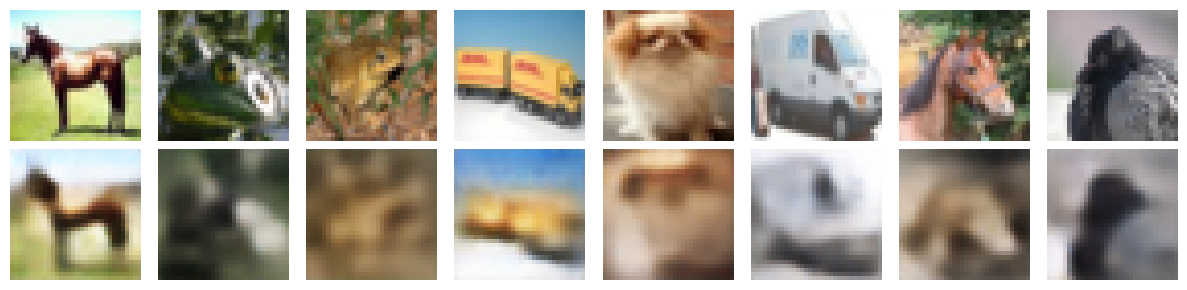

In [52]:

model.eval()

with torch.no_grad():
    test_data = next(iter(test_loader))[0][:8].to(device)
    recon, _, _ = model(test_data)

# generated by claude
# ---
fig, axes = plt.subplots(2, 8, figsize=(12, 3))

for i in range(8):
    # Original image
    orig_img = test_data[i].cpu().reshape(3, 32, 32).permute(1, 2, 0)
    axes[0, i].imshow(orig_img, cmap='gray_r')
    axes[0, i].axis('off')
    # Reconstructed image
    recon_img = recon[i].cpu().reshape(3, 32, 32).permute(1, 2, 0)
    axes[1, i].imshow(recon_img, cmap='gray_r')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', size=12)
axes[1, 0].set_ylabel('Reconstructed', size=12)
plt.tight_layout()
# plt.savefig('conv_v1_vae.png')
plt.savefig('conv_v2_vae.png')
# ---

## Part 2: Discrete VAE

Your task now is to implement a discrete VAE, where the latent space has a categorical distribution with $d$ dimensions and $k$ possible categories for each dimension (we one-hot to $d \times k$ tensors). Some things to keep in mind:

- The encoder yields logits, which are then converted to $d \times k$ tensors. Sampling is achieved through the Gumbel Softmax trick.
- The decoder takes one-hot $d \times k$ tensors as input and produces an output.
- The prior for $z$ is a uniform categorical distribution.
- Training is a combination of reconstruction loss and latent loss (D_{KL} between a uniform categorical distribution and encoder categorical distribution: See notes for exact mathematical form).
- The temperature parameter for the gumbel softmax should be decreased over the course of training.

### Model Structure:


#### Encoder

- The encoder will yield *logits* for each dimension. These logits will then be used to approximate sampling from a categorical distribution using the Gumbel Softmax trick (include a temperature parameter)

- Use the straightthrough trick to pass a hard categorical sample to the decoder, but preserve gradients for backpropagation. The samples from $z$ will be $d \times k$ tensors.


#### Decoder

The decoder will take one-hot $d \times k$ tensors as input. Reshape and pass through the rest of the decoder network to construct the output.


#### Suggested structure:

I suggest the following basic structure and workflow for your model components:

**Encoder**

```
## Discrete VAE Encoder

class dVAE_Encoder(nn.Module):

    def __init__(self, input_dim, d, k):
        ...

    # Reshape final linear layer output to z_dim x k_cats -> Gives logits
    def forward(self, x):
        ...
```

**Decoder**

```
## Discrete VAE_Decoder

class dVAE_Decoder(nn.Module):

    
    def __init__(self, d, k, output_dim):
        ...

    # Expects one-hot encoded input
    # Take one-hot matrix of size d x k, reshape and pass through linear layers to get output
    def forward(self, z):
        ...
```

**Discrete VAE**

```
class DiscreteVAE(nn.Module):

    def __init__(self, input_dim, d, k):
        ...
        
    # Approx sample from categorical distribution given the logits and the temp for the gumbel softmax
    def get_discrete_sample(self, logits, temp):
        
        # Calculate a y_soft and y_hard
        # Use straightthrough trick to assign gradients to y_hard
        # Return y_hard


    # Run the model in training mode: Takes input image and temp for gumbel softmax
    def forward(self, x, temp):

        # First encode: Get the logits (as matrix for each obs in batch)
        # Get z as categorical sample using logits and temp: will be d by k
        # Decode and return both x_out and the logits
```

Exact implementation details including model structure, number of layers, etc., are up to you.


### Training and Deliverables

As indicated above, train (on the CIFAR10 data) using reconstruction and latent loss (see notes for latent loss details)

And as before, after training:

1. Visually assess the ability of the model to reconstruct input images on a few sample images
2. Create some examples of generated images sampling from the latent space (sample from a uniform categorical distribution)


## Answers

Discrete VAEs are a variation of VAEs, instead of picking $\mu \text{ or } \sigma$ from the encoder, the encoder spits out unnormalized (-inf to inf) logits, 

then we use gumbel softmax trick (the temperature hyperparameter here is decreased over the course of training) to get those rough logits [x,y,z...] from encoder in k(categories) * d(model dimension) dimensions by sampling, 


so then the decoder takes that and one hots d*k tensors as input and produces an output


in training the loss function has reconloss + latent_loss (KL) between unifrom categorial distribute and encoder categorical distribution

I will be using Conv approach for this since we have CIFAR dataset



<img src="./vae/dvae.excalidraw.png">

#### Encoder

- get input image
- pass through layers with ReLU and downsamplign trhough latent channel 
- flatten to  latent*k dimension linear layer
- return 

In [5]:
class D_Encoder(nn.Module):
    def __init__(self, in_channel, latent_channel, kernel_size, stride, padding, input_dim, latent_dim ):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channel, latent_channel // 4, kernel_size, stride, padding)
        self.bn1=nn.BatchNorm2d(latent_channel // 4)
        
        self.conv2 = nn.Conv2d(latent_channel // 4, latent_channel // 2, kernel_size, stride, padding)
        self.bn2 = nn.BatchNorm2d(latent_channel // 2)
        
        self.conv3 = nn.Conv2d(latent_channel // 2, latent_channel, kernel_size, stride, padding)
        self.bn3 = nn.BatchNorm2d(latent_channel)
        
        self.linear = nn.Linear(input_dim, latent_dim)
        
        self.relu = nn.ReLU()
        
        self.pool = nn.MaxPool2d(2)

        

    def forward(self, x):
        x = self.bn1(self.relu(self.conv1(x)))
        x = self.pool(x)
        x = self.bn2(self.relu(self.conv2(x)))
        x = self.pool(x)
        x = self.bn3(self.relu(self.conv3(x)))
        
        x = x.view(x.size(0), -1)
        
        x = self.linear(x)
        

        return x

#### Decoder

- get latent vector input from encoder as flat tensor (our discrete choices, flattened back out)

- use linear layer to project that vector into a large enough size so it can be reshaped back into 3d (Channels × Height × Width).

- use conv transpose layers to grow the spatial dimensions (from 4×4 back up to 32×32) and shrink the channels back to 3 (for an RGB image).

In [6]:
class D_Decoder(nn.Module):
    # 4x4 -> 8x8 -> 16x16 -> 32x32
    def __init__(self, in_channel, out_channel, kernel_size, stride, padding, latent_dim, hidden_dim, output_padding):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        
        self.linear = nn.Linear(latent_dim, hidden_dim *16) 
        
        self.convT1 = nn.ConvTranspose2d(hidden_dim, hidden_dim // 2, kernel_size, stride, padding, output_padding)
        self.bn1 = nn.BatchNorm2d(hidden_dim // 2)
        
        self.convT2 = nn.ConvTranspose2d(hidden_dim // 2, in_channel, kernel_size, stride, padding, output_padding)
        self.bn2 = nn.BatchNorm2d(in_channel)
        
        self.convT3 = nn.ConvTranspose2d(in_channel, out_channel, kernel_size, stride, padding, output_padding)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid() 

    def forward(self, x):
        x = self.linear(x) # batchsize, hiddendim
        x = x.view(x.size(0), self.hidden_dim, 4, 4) # hidden dim, 4, 4
        x = self.bn1(self.relu(self.convT1(x)))
        x = self.bn2(self.relu(self.convT2(x)))
        x = self.convT3(x)

        x = self.sigmoid(x) # for final pixel values between 0 and 1
        
        return x

#### VAE

- get intput
- pass input to encoder and get latent*k dimensioned flat vectors 
- reshape those flat vectors into logits 
- apply gumbel softmax trick with the temperature (needs to be lowered)
    - add gumbel noise
    - apply softmax (y_soft)
    - get argmax and one hot the y_hard
    - apply straight through estimator trick
- get latent vector
- pass the latent vector to decoder
- get output 

**Gumbel Softmax Trick**

we use GST because in neural network, we want backpropagation to work that means the things should have derivatives in order to calculate gradients,
in discrete vae however, we're making hard choices, so normally picking a category with argmax won't be an option since it's just a step function and the slope of it is natrually just 0, so we need some form of noise or something that isn't such hard, 

so we instead use a controlled randomness noise called gumbel noise, why is it called gumbel? The Gumbel-Softmax trick is named after the Gumbel distribution, which is the specific type of "noise" added to the model's unnormalized log-probabilities (logits) to enable sampling.


we work this by adding a gumbel noise that basically samples different categories K rather than just pickign the absolute highest value every single time, so it becomes the ifs and elses of neural netwroks, we also add a softmax and temperature after that sampling such that, the noisy values gets squished itno probabilities and temperature controls how smooth that is. so now we have configruable ifs and elses and thus this is differentiable, so it solves the gradient problem.



$$
y_i = \frac{\exp\!\left((h_i + g_i)/\tau\right)}
{\sum_{j=1}^{k}\exp\!\left((h_j + g_j)/\tau\right)}
$$

$h_i$​: the raw, unnormalized logit coming directly from your encoder.

$g_i$:  gumbel noise. we generate this by pulling a random uniform number u between 0 and 1, and calculating gi​=−log(−log(u)).

$\tau$: the temperature parameter.

we use this temp paramtere in  training dynamically,because temperature controls the osftness or hardness of the categorical sampling in this trick, if the $\tau$ is high, the gradient is smoother and more exploratory, model focuses on everything  equally, so we start with high and decrease as we go further  

**Straight Through Estimator Trick**

now that we have the soft probabilities softmaxed from the gumbel trick, in true discrete vae we still need to be discrete so keepping just that would violate our requiremetns, so now instead of argmax, w edecouple the forward pass from backward pass with pytorch math,

we have :

y_soft -> gumbel noised y, softmaxed with temperature logits (ifs and elses configurable -> it WILL be noticed by torch NN)

y_hard -> highest prob in y_soft logits, converted into strict one hot vector (Argmaxed -> so it will be ignored by torch NN)

so we want to influence discretness without influencing torch's gradient property, so we do :

$$y = \underbrace{y_{\text{hard}} - y_{\text{soft}}.\texttt{detach()}}_{\text{non-differentiable (ignored)}} + \underbrace{y_{\text{soft}}}_{\text{differentiable}}$$

In [7]:
class D_VAE(nn.Module):
    def __init__(self, in_channel, latent_channel, out_channel, kernel_size, stride, padding, input_dim, latent_dim, hidden_dim, output_dim, d_latent_cat_grid, k_categories, gs_temp):
        # in normal vae, latent space is a single flat list of numbers but in DVAE, the latent space is a grid made up of d latent dimension of each categorical variables, with each variable having k possible options to choose from
        # Essentially, d controls the width of latent representation, and k controls the number of distinct states each part of that representation can take
        
        super().__init__()
        
        self.encoder = D_Encoder(in_channel, latent_channel, kernel_size, stride, padding, input_dim, latent_dim)
        
        self.decoder = D_Decoder(latent_channel,out_channel, kernel_size, 2, padding, latent_dim, hidden_dim, 1)
        
        # increasing latent dimension of each category encourages feature disentanglement — the model can learn independent, higher-level traits.
        self.d_latent_cat_grid = d_latent_cat_grid
        # increasing k categories encourages granularity — the model can represent more precise variations within a single feature.
        self.k_categories = k_categories
        self.gs_temp = gs_temp # hyperparam for temp of gumbel softmax trick, increasing this will increase std of probabilities that means, higher randomness since the 
        # values of the input probaiblities are normalized instead of highs or lows, resulting in high entropy and more exploration, vice versa
         
    def gumbel_softmax(self, x):
        """adds gumbel noise and applies softmax with temp \tau; y_soft"""
        # x : batchsize, d_latent_cat_grid, k category
        # u = torch.rand(x.shape) # unoptimized for gpu
        u = torch.rand_like(x)
        noise = - torch.log(- torch.log(u))
        
        # y_soft = torch.exp((x + noise) / self.gs_temp) / torch.sum(torch.exp((x + noise)/ self.gs_temp), dim=-1).unsqueeze(2) # we have to torch.sum only over last_dim=-1 since its k categories
        y_soft = F.softmax((x+noise) / self.gs_temp, dim=-1)
        
        return y_soft
    
    def straight_through_estimator(self, y_soft):
        """takes argmax from y_soft and one hots; y_hard"""
        
        # get biggest value indices from the soft distribution
        hard_indices = y_soft.argmax(dim=-1)
        
        # one hot it
        
        y_hard = nn.functional.one_hot(hard_indices, num_classes=self.k_categories).float() # by default it might not be float
        
        # the equation, we use .detach to ignore a differentiable torch property from being influenced in gradients
        ste = y_hard - y_soft.detach() + y_soft
        
        return ste 
    
    def forward(self, x):
        
        x = self.encoder(x) # batch_size, latent_dim
        
        assert not (x.isnan().any()), "Nan found from encoder!"

        x = x.view(x.size(0), self.d_latent_cat_grid, self.k_categories) # [batchsize, d dimesnions per category, k categories]
        
        x_soft = self.gumbel_softmax(x) # softer probabiltiies with differentiable  di
        
        assert not (x_soft.isnan().any()), "Nan found from gumbel_softmax!"
        
        x = x_soft
        
        
        x = self.straight_through_estimator(x) # harder probabilities 
        # batch_size, d, k
        
        assert not (x.isnan().any()), "Nan found from striaght_through_estimator!"
        
        x = torch.flatten(x, start_dim=1) # batchsize, latent_dim
        
        recon = self.decoder(x) # batchsize, 3, 32, 32
        assert not (recon.isnan().any()), "Nan found from decoder!"

        return recon, x_soft, self.k_categories

#### Training

- get images
- run for loop over epoch
- for each epoch, run a for loop over the batch of images
- pass the current image to model and get output
- compute recon error and kl divergence
    - use y_soft and k for kl divergence
    - combine total loss
- backpropagation and use optimizer for updatig weights 
- also apply annealing step 

In our loss function for DVAE,

we have KL divergence as usual and recon loss, but here the difference is that in D_VAE, we don't just have one variable; we have a grid of d variables (where d=self.d_latent_cat_grid). To get the total latent loss for the whole model, we sum the KL divergence across all d variables and then average over the batch

In a batch of data, we calculate this for every one of our d latent variables. If y_soft is your tensor of probabilities with shape [batch_size, d_latent_cat_grid, k_categories]:




Reconstruction loss could be either of
$$ \text{MSE} = \frac{1}{N} \sum(x - \hat{x})^2 $$

or

$$ \text{BCE} = - \frac{1}{N} \sum [x \log (\hat{x}) + (1-x)\log(1-\hat{x})] $$

where:

$x$ : is the target real input image from cifar dataset, since we will normalize images before feeding to NN, x is the acttual pixel color intensities from 0 to 1

$\hat{x}$ : is the reconstructed image coming out of decoder, since we have sigmoid activation in last layer, $\hat{x}$ is guaranteed to be a decimal between 0 to 1

$\sum$ : we calculate the erro for every single pixel individually and then add them together before dividing by $N$ to get the average

The KL divergence equation differs for DVAE and FC_VAE,
[FC_VAE KL divergence equation explained above.](#kl_divergence)

since in FC_VAE, we assume that the latent variables are continuous numbers, and that they follow a gaussian distribution, and the model there predicts the mean and variance to fomr the bell curve, where the target is standard normal distribution, so KL here tries to compare the two continuous bell curves that require calculus, the result of that integral gives the standard VAE formula, but in D_VAE, the latent variables are in distinct categories i.e independent probabilities NOT continuous, and we model them using categorical distribution NOT gaussian, so here model predicts discrete list of probs, where KL measures the difference between two discrete bar charts and then we sum them up normally  

$$ D_{KL} =  \sum q_i \log(q_i + \epsilon) + log(k)$$

where :

$q_i$ is the input

$\epsilon$ is there to prevent log(0) error in pytorch and annealing

$k$ is the number of categories


- We calculate qlog(q) for every element.

- We sum over the k categories (the last dimension)

- We add log(k).

- We average over the batch and the d variables.


$$ \text{Total Loss=Reconstruction Loss + β⋅KL Divergence} $$

β:  we start β at 0 and slowly increase it (annealing) so the model learns to reconstruct before it worries about the latent distribution.

basically beta controls relative weight of KL loss in the total vae loss



$$ \underbrace{\log{P(X)}}_{\text{want to max}} - \underbrace{D_{KL}[Q(z|X)||P(z|X)]}_{\text{error term}} = E_{z \sim Q}[ \underbrace{[\log{P(X|z)}]}_{\text{reconstruction; error/score}} - \underbrace{D_{KL}[Q(z|X)||P(z)]}_{\text{latent error}} ]$$

In [13]:
imgs, label = next(iter(train_loader))
b, c, h, w = imgs.shape
# input_dim_flat = c * h * w
input_dim_flat = imgs.view(b, -1).shape[1]

input_dim = input_dim_flat
print("original input shape", imgs.shape)
print("Flattened input",input_dim)

original input shape torch.Size([32, 3, 32, 32])
Flattened input 3072


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

k_categories and dlatentcatgrid, must multiply to equal our latent_dim (64).

In [21]:
model = D_VAE(
    in_channel=3, 
    latent_channel=128, 
    out_channel=3, 
    kernel_size=3,      
    stride=1,           
    padding=1,          
    input_dim=128*8*8,  # flattened size after the encoder's max pools
    latent_dim=256, 
    hidden_dim=128,     
    output_dim=3072,    
    d_latent_cat_grid=16, # how many features model is allowed to learn
    k_categories=16, # how many distincto ptions or variations each of those features can have
    gs_temp=1.0         # Starting temperature for Gumbel-Softmax
).to(device)

In [22]:
optimizer = torch.optim.Adam(params= model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss(reduction="sum")
epochs = 50

In [ ]:
import math

model.train()
# - get images
# - run for loop over epoch
# - for each epoch, run a for loop over the batch of images
# - pass the current image to model and get output
# - compute recon error and kl divergence
#     - use y_soft and k for kl divergence
#     - combine total loss
# - backpropagation and use optimizer for updatig weights 
# - also apply annealing step 

beta=0.0
for epoch in range(epochs):
    total_loss = []
    _recon_loss = []
    _kl_loss=[]
    eps = 1e-10
    beta = min(1.0, epoch / (epochs * 0.5)) # annealing (basically increasing beta over epochs so model first pays attention to reconstruction loss then latent)
    model.gs_temp = max(0.1, 1.0 * (0.95 ** epoch)) # temperature annealing starts at 1.0, decays towards 0.1 over epochs
    
    for imgs, _ in train_loader:
        imgs = imgs.to(device)

        # [batchsize, d_latent_cat_grid, k_categories]
        recon, x_soft, k_categories = model(imgs)
        # print("recon: ", recon)
        # print("x_soft", x_soft)
        # print("k_categories", k_categories)
        assert not (recon.isnan().any() or x_soft.isnan().any()), "Nan found!"
        
        # [batch_size, d_latent_cat_grid]
        K_loss = torch.sum(x_soft * torch.log(x_soft + eps), dim=-1) + math.log(k_categories) # we only want to sum over k categories

        # single number
        K_loss = K_loss.mean()
        
        # print("recon.shape:",recon.shape)
        # print("imgs.shape:",imgs.shape)
        

        recon_loss = loss_fn(recon, imgs)
        
        loss = recon_loss + beta * K_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss.append(loss.item())
        _kl_loss.append(K_loss)
        _recon_loss.append(recon_loss)


    print(f"Epoch : {epoch}, Temp: {model.gs_temp:.4f}, Mean Loss : {sum(total_loss)/len(total_loss)}, KL Loss : {sum(_kl_loss)/len(_kl_loss)}, Recon Loss : {sum(_recon_loss)/len(_recon_loss)}")


Epoch : 0, Temp: 1.0000, Mean Loss : 3087.077462633832, KL Loss : 1.935925841331482, Recon Loss : 3087.078369140625
Epoch : 1, Temp: 0.9500, Mean Loss : 2241.1422004333613, KL Loss : 2.1383981704711914, Recon Loss : 2241.056884765625
Epoch : 2, Temp: 0.9025, Mean Loss : 2147.5985179273885, KL Loss : 2.2164440155029297, Recon Loss : 2147.419921875
Epoch : 3, Temp: 0.8574, Mean Loss : 2095.0287084695397, KL Loss : 2.2676095962524414, Recon Loss : 2094.754638671875
Epoch : 4, Temp: 0.8145, Mean Loss : 2069.6825926640977, KL Loss : 2.3081278800964355, Recon Loss : 2069.315185546875
Epoch : 5, Temp: 0.7738, Mean Loss : 2047.804345500065, KL Loss : 2.342367172241211, Recon Loss : 2047.336669921875
Epoch : 6, Temp: 0.7351, Mean Loss : 2021.0255194900133, KL Loss : 2.375164270401001, Recon Loss : 2020.455322265625
Epoch : 7, Temp: 0.6983, Mean Loss : 2013.04599684351, KL Loss : 2.405939817428589, Recon Loss : 2012.3704833984375
Epoch : 8, Temp: 0.6634, Mean Loss : 1992.3857860797045, KL Loss :

In [24]:
# torch.save(model.state_dict(), "d_vae.pt")
torch.save(model.state_dict(), "d_vae2.pt")

### Eval

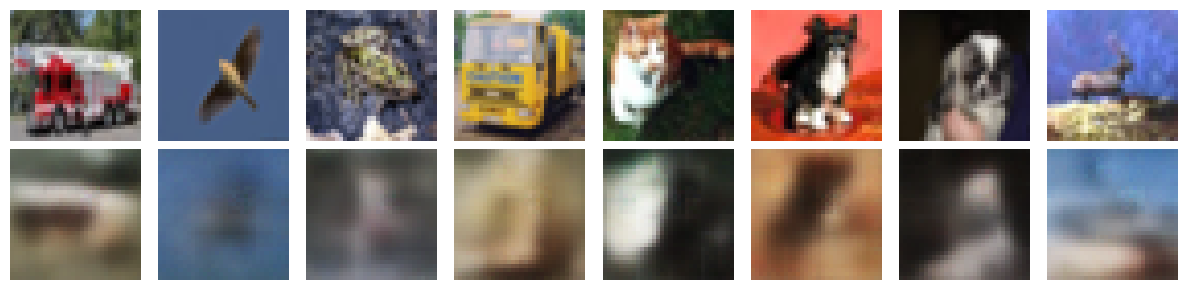

In [27]:
model.eval()
with torch.no_grad():
    test_data = next(iter(test_loader))[0][:8].to(device)  # shape: [8, 3, 32, 32]
    recon, _, _ = model(test_data)  # recon shape: [8, 3, 32, 32]

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    # Original image
    orig_img = test_data[i].cpu().permute(1, 2, 0)
    axes[0, i].imshow(orig_img, cmap='gray_r')
    axes[0, i].axis('off')
    # Reconstructed image
    recon_img = recon[i].cpu().permute(1, 2, 0)
    axes[1, i].imshow(recon_img, cmap='gray_r')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', size=12)
axes[1, 0].set_ylabel('Reconstructed', size=12)
plt.tight_layout()
# plt.savefig('v1_dvae.png')
plt.savefig('v2_dvae.png')

In [20]:
!ls

data  d_vae2.pt  sample_data  v2_dvae.png


## Part 3: "YOLOv0"

Our goal here is to implement a YOLO-like model for object detection using the Pascal VOC 2012 dataset.

#### Implement a model that:

1. Detect objects across a 7x7 grid: The model should yield a final output of shape 7x7x26
2. For each gridcell there are 26 outputs: 4 coordinates (center x, center y, width, height) for a single bounding box, 1 objectness score, and 21 class scores (including a background class)
3. Note that center x and y coordinates are relative to the gridcell, while height and width are relative to the image.

Your model should consist of a CNN backbone (decide the details yourself), followed by a fully connected net that yields outputs that are reshaped to a final 7x7x26 shape. Alternatively, you can use a fully convolutional architecture.


#### Load the Pascal VOC data appropriately

- The 2012 Pascal VOC data is included with this lab (download link for 2012 data from University of Oxford currently appears to be broken, though some earlier years appear available; Kaggle may also be an alternative for downloading).

- The code below loads the data into a format chosen by your instructor, including Datasets and DataLoaders.

- Alternatively you can use the lecture notebooks and `load_yolo.py` for examples of parsing the XML annotations to extract bounding box and class data for the various images if you want to use a different format...


####  Train your model

- Every ground truth object should be assigned to a single gridcell based on center coordinates.

- You should have three basic loss terms:

1. Coordinate loss: Use MSE for center x and center y coordinates, and MSE for the square root of height and width. Only calculate a coordinate loss for gridcells that have an associated ground truth box. Scale coordinate loss by a factor of `5`.
2. Confidence loss: Use MSE on your objectness score vs. ground truth; weight cells that do not have a groun truth box by a factor of `0.5`.
3. Class loss: Use cross-entropy loss for object class; ignore the background class


#### Implement Non-Max Suppression for Inference and visualize

- Implement the non-max suppression (NMS) algorithm for inference, using reasonable objectness and IoU thresholds.
- Visualize the results of your object detection model on some example inputs

#### The following cells will load the data and visualize some examples

- Make sure you extract the data and set the path name appropriately
- Be sure you downloaded `load_yolo.py` as well

## Answers


- in CNNs, the number of output channels determine the number of classes to predict Yolo: B(5+C) channels i.e boxes -> boxes predicted, C -> num of classes, 5 -> params to describe a box (4 coords + confidence)
- FC CNNs is where there are independent biases per neuron 

In Object detection there are two ways to go about it:

 one is 2 stage detectors that RCNN uses :
1. Region Proposal algorithm
2. CNN predicts classes + objectness on proposed regions
3. refine box coords
4. Non max supression and other post processing for classification

or what YOLO/SSD uses:
1. predict boxes/classes directly with respect to the grid of possible object centers or predefined anchor boxes


<img src="./yolo/image15.png" width=540>

In faster RCNN, we predict center point from respect to bounding/anchor boxes
but in yolo this caused training instability, they relied back on relying on grid value offsets 

anchor boxes are predefined set of shapes that who serve as reference to anchor boxes

<img src="./yolo/image.png" width=540>

the way to train yolo would be : 
- Pretrain on N classes imagenet dataset annotated
- object detection where SSE as a loss function 
- add degrees of data augmented techniques for improving performance like exposure, tranlsation, position
- add non max supression in inference time 

<img src="./yolo/image2.png" width=540>
<img src="./yolo/image3.png" width=540>
<img src="./yolo/image4.png" width=540>
<img src="./yolo/image5.png" width=540>

yolov2 -> better and stronger
- batch normalization in all CNN layers
- fine tune classification network on higher resolution images
- Imagenet classification -> imagenet classification -> detection finetuning
- each grid cell, model makes prediction as offsets from set of predefined pre anchor boxes, rather than predicting box parameters, we predict parameters that will transform these predefined anchor boxes to prediction boxes -> How to transform existing boxes
- removed fc layers with CNN layers, remove pooling layer to make output high resolution 
- use odd number grid for easier center detection
- predict localization offsets, class and objectness scores for every anchor box
- rather than predetermining what anchor box sizes, we use K means clustering to pick prior boxes -> 
-  three basic loss terms:
1. Coordinate loss: Use MSE for center x and center y coordinates, and MSE for the square root of height and width. Only calculate a coordinate loss for gridcells that have an associated ground truth box. Scale coordinate loss by a factor of `5`.
2. Confidence loss: Use MSE on your objectness score vs. ground truth; weight cells that do not have a groun truth box by a factor of `0.5`.
3. Class loss: Use cross-entropy loss for object class; ignore the background class
- uses fine grained features for better localization on smaller objects by adding a pass through layer or skip connectip type thing - The passthrough layer takes features from an earlier, higher-resolution layer (specifically a 26x26 feature map) and brings them to the final layer
- This high-resolution feature map is rearranged and concatenated with the lower-resolution, semantically stronger features from the final layer
- Ground truth objects are now assigned to the prior box (anchor box) that has the highest IOU with the target, rather than just the grid cell center
- For the responsible predictor box, the objectness loss is calculated as the Mean Squared Error (MSE) between the target IOU and the predicted score
- Predictor boxes with an IOU below a certain threshold are treated as background, and their loss is based on the MSE between zero and the predicted score
- TX and TY (Center): The loss is MSE between the predicted center offsets (constrained by sigmoid) and the target offsets from the grid cell corner.
- TW and TH (Size): The loss is MSE between the predicted transformation parameters and the target log-space transformation to match the anchor box dimensions
- FC layers were preventing yolo from predicting more classes "higher recall", so they moved on from fc layers to fully convoluntional layers with fixed kernels
- uses darknet instead of googlenet


<img src="./yolo/image6.png" width=540>
<img src="./yolo/image7.png" width=540>
<img src="./yolo/image8.png" width=540>
<img src="./yolo/image9.png" width=540>
<img src="./yolo/image10.png" width=540>
<img src="./yolo/image11.png" width=540>
<img src="./yolo/image12.png" width=540>
<img src="./yolo/image14.png" width=540>



all in all yolov1 is :
- pretraining of googlenet on imagenet dataset for feature extraction, this involves convolution operations to create abstract representations of images. If an input has a pixel value $x$ and a convolutional filter has weight $w$ and bias $b$, the output $y$ is computed as:
$y = \sum(x \times w) + b$, These layers are optimized to minimize the error in classifying 1,000 different object categories.

- modify googlenet to remove classification heads or final layers and detection heads basically four convolutional layers and two fully connected layers

- this modified classfiication cnn into a object detection cnn

- The input image is conceptually divided into an $S \times S$ grid (e.g., $7 \times 7$). To assign an object to a cell, the algorithm calculates the center $(x_c, y_c)$ of the ground truth box. If $(x_c, y_c)$ falls within a specific grid cell, that cell is responsible for predicting that object (05:50).

- For every grid cell, the model predicts two bounding boxes ($B=2$). Specifically, it predicts five parameters for each box: the center X and Y coordinates (as an offset from the top-left corner of the cell), the width and height of the box (normalized relative to the image size), and a confidence score. Each cell predicts $B$ bounding boxes ($B=2$ in V1). For each box, it predicts 5 parameters: 
    - Center $(x, y)$: Offsets relative to the top-left corner of the specific grid cell, normalized between $0$ and $1$.
    - Width ($w$) and Height ($h$): Normalized relative to the entire image dimensions.
    - Confidence Score: A measure of how likely an object exists in that box and how well it fits.
    
    each grid cell can contain only one class

- we pick the bounding box that has the highest IoU with the ground truth box -> Non Max Supression, addressing the same error in small box is worse than in the large box issue

- The confidence score is computed as the product of the probability that an object exists in the box and the Intersection over Union (IOU) between the predicted box and the ground truth box. This helps the model distinguish between a box that is just empty space and a box that tightly fits an object. The confidence score is defined as:
    $Confidence = Pr(Object) \times IOU_{pred}^{truth}$
    If no object exists in the cell, $Pr(Object) = 0$.
    If an object exists, $Pr(Object) = 1$. The score is then exactly the Intersection over Union (IOU) between the predicted box and the ground truth box.

- Each grid cell independently predicts conditional class probabilities: $Pr(Class_i | Object)$. This represents the likelihood that the object belongs to class $i$, given that an object exists in that cell. For the VOC dataset, this is a vector of 20 probabilities.

- YOLO reduces detection to a regression problem using Mean Squared Error (MSE) to minimize the difference between predicted values and ground truths.
    - Localization Loss (Bounding Box): the square root of width and height ($\sqrt{w}, \sqrt{h}$) instead of $w$ and $h$ directly. Because the square root function has a steeper slope for smaller values, a small absolute error in a small box produces a larger loss value than the same error in a large box, effectively punishing errors on small objects more heavily.
    - Loss Scaling: To balance the loss function, two scaling parameters are used:
        - Lambda-coord: Increases the weight of localization errors (set to 5).
        - Lambda-noobj: Decreases the weight of confidence errors for cells containing no objects (set to 0.5).
    - Confidence Loss: Measures the error in the predicted confidence score, which indicates if an object is present and how well the box fits. It treats cells with objects and cells without objects differently based on a scaling factor.
    - Class Probability Loss: Penalizes incorrect class predictions for cells that actually contain an object.
    
- yolov1 uses Mean Squared Error (MSE) as its loss function, combining three components:
    - 1. Localization Loss (Bounding Box)
        Penalizes errors in predicted bounding box coordinates:
        $$L_{coord} = \lambda_{coord} \sum_{i=0}^{S^2} \sum_{j=0}^{B} \mathbb{1}_{ij}^{obj} \left[ (x_i - \hat{x}_i)^2 + (y_i - \hat{y}_i)^2 + (\sqrt{w_i} - \sqrt{\hat{w}_i})^2 + (\sqrt{h_i} - \sqrt{\hat{h}_i})^2 \right]$$
        here we use $\sqrt{w}$ and $\sqrt{h}$ instead of raw dimensions to penalize small object errors more heavily
        - $\lambda_{coord} = 5$ (scaling factor to emphasize localization accuracy)
        - Only applied to cells containing ground truth objects ($\mathbb{1}_{ij}^{obj} = 1$)

    - 2. Measures accuracy of objectness predictions:
        $$L_{conf} = \sum_{i=0}^{S^2} \sum_{j=0}^{B} \left[ \mathbb{1}_{ij}^{obj} (C_i - \hat{C}_i)^2 + \lambda_{noobj} \mathbb{1}_{ij}^{noobj} (C_i - \hat{C}_i)^2 \right]$$
        - $\lambda_{noobj} = 0.5$ (reduces weight for empty cells to balance positive/negative examples)
        - Penalizes both false positives and false negatives
    - 3. Class Probability Loss:
        Cross-entropy loss for class predictions (only for cells with objects):
        $$L_{class} = \sum_{i=0}^{S^2} \mathbb{1}_{i}^{obj} \sum_{c \in classes} (p_i(c) - \hat{p}_i(c))^2$$

thus, the total loss is : 
$$L_{total} = L_{coord} + L_{conf} + L_{class}$$


<img src="./yolo/image13.png" width=540>
loss for yolov2
<img src="./yolo/image16.png"  width=540>



#### Getting Data

In [4]:
from load_yolo import YOLODataset

In [5]:
#Dictionary to go from class name to an index:
class_dict = {
    'background': 0,
    'aeroplane': 1,
    'bicycle': 2,
    'bird': 3,
    'boat': 4,
    'bottle': 5,
    'bus': 6,
    'car': 7,
    'cat': 8,
    'chair': 9,
    'cow': 10,
    'diningtable': 11,
    'dog': 12,
    'horse': 13,
    'motorbike': 14,
    'person': 15,
    'pottedplant': 16,
    'sheep': 17,
    'sofa': 18,
    'train': 19,
    'tvmonitor': 20
}


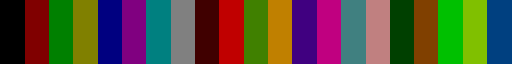

In [6]:
#Make a colormap for classes:
#Will use below

from matplotlib.colors import ListedColormap

VOC_COLORMAP = np.array([[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]) / 255

voc_cmap = ListedColormap(VOC_COLORMAP)

voc_cmap

In [7]:
!ls 

load_yolo.py  __pycache__  sample_data


In [8]:
!cat load_yolo.py

import xml.etree.ElementTree as ET
import os
from PIL import Image
from torchvision.tv_tensors import BoundingBoxes

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as transforms

from torch.utils.data import Dataset, DataLoader


#Will return image + SxS tensors: x, y, w, h, conf, class
class YOLODataset(Dataset):
    
    ## Link to files indicated in jpeg_list/annotation_list, will convert to desired res
    def __init__(self, jpeg_list, annotation_list, S=7, res=128, addtl_transform=None):

        self.jpeg_list = jpeg_list
        self.annotation_list = annotation_list


        #Number of gridcells as SxS
        self.S = S
        
        #Save desired resolution
        self.res = res
        
        #Any additional transform
        self.addtl_transform=addtl_transform
        
        
        #Helper dictionary to go from class name to an index:
        self.class_dict = {
         

In [9]:
!python3 load_yolo.py 

In [10]:
!pip install kaggle

In [ ]:
import os

# Set your Kaggle credentials
os.environ["KAGGLE_USERNAME"] = "ashworks1706"
os.environ["KAGGLE_KEY"] = "KGAT_a6064c22d86d6e73e6fb6f4732a0b766"



In [13]:
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

api.dataset_download_files(
    "huanghanchina/pascal-voc-2012",
    path="./",
    unzip=True
)


Dataset URL: https://www.kaggle.com/datasets/huanghanchina/pascal-voc-2012


In [14]:
!mv VOC2012/* ./

In [15]:
import os

# Get all JPEG filenames (without .jpg extension)
jpeg_dir = './JPEGImages'
image_ids = sorted([f[:-4] for f in os.listdir(jpeg_dir) if f.endswith('.jpg')])

# Create ImageSets/Main directory if needed
os.makedirs('./ImageSets/Main', exist_ok=True)

# Write to trainval.txt
with open('./ImageSets/Main/trainval.txt', 'w') as f:
    f.write('\n'.join(image_ids))

print(f"Created trainval.txt with {len(image_ids)} images")

Created trainval.txt with 17125 images


In [16]:
## Construct your train/validation datasets:

voc_dir = './'

import os

## Get file numbers for the training+validation sets:
train_num_file = os.path.join(voc_dir, 'ImageSets', 'Main', 'trainval.txt')

# Open and get the numbers for the train set:
with open(train_num_file, 'r') as fp:
    train_nums = fp.read().split()

num_list = train_nums

# FIX: Use forward slashes or os.path.join() for cross-platform compatibility
jpeg_dir = os.path.join(voc_dir, 'JPEGImages')
annotations_dir = os.path.join(voc_dir, 'Annotations')

# Create proper path lists
jpeg_list = [os.path.join(jpeg_dir, i + '.jpg') for i in num_list]
annotations_list = [os.path.join(annotations_dir, i + '.xml') for i in num_list]

print(f"Found {len(jpeg_list)} images")
print(f"Sample image path: {jpeg_list[0]}")
print(f"Sample annotation path: {annotations_list[0]}")

Found 17125 images
Sample image path: ./JPEGImages/2007_000027.jpg
Sample annotation path: ./Annotations/2007_000027.xml


In [17]:
!ls -lah

total 1.4M
drwxr-xr-x 1 root root 4.0K Mar 18 00:35 .
drwxr-xr-x 1 root root 4.0K Mar 18 00:31 ..
drwxr-xr-x 2 root root 536K Mar 18 00:35 Annotations
drwxr-xr-x 4 root root 4.0K Jan 16 14:24 .config
drwxr-xr-x 6 root root 4.0K Mar 18 00:35 ImageSets
drwxr-xr-x 2 root root 552K Mar 18 00:35 JPEGImages
-rw-r--r-- 1 root root 8.7K Mar 18 00:34 load_yolo.py
drwxr-xr-x 2 root root 4.0K Mar 18 00:34 __pycache__
drwxr-xr-x 1 root root 4.0K Jan 16 14:24 sample_data
drwxr-xr-x 2 root root 112K Mar 18 00:35 SegmentationClass
drwxr-xr-x 2 root root 112K Mar 18 00:35 SegmentationObject
drwxr-xr-x 3 root root 4.0K Mar 18 00:35 voc2012
drwxr-xr-x 2 root root 4.0K Mar 18 00:35 VOC2012


In [18]:
annotations_list

['./Annotations/2007_000027.xml',
 './Annotations/2007_000032.xml',
 './Annotations/2007_000033.xml',
 './Annotations/2007_000039.xml',
 './Annotations/2007_000042.xml',
 './Annotations/2007_000061.xml',
 './Annotations/2007_000063.xml',
 './Annotations/2007_000068.xml',
 './Annotations/2007_000121.xml',
 './Annotations/2007_000123.xml',
 './Annotations/2007_000129.xml',
 './Annotations/2007_000170.xml',
 './Annotations/2007_000175.xml',
 './Annotations/2007_000187.xml',
 './Annotations/2007_000241.xml',
 './Annotations/2007_000243.xml',
 './Annotations/2007_000250.xml',
 './Annotations/2007_000256.xml',
 './Annotations/2007_000272.xml',
 './Annotations/2007_000323.xml',
 './Annotations/2007_000332.xml',
 './Annotations/2007_000333.xml',
 './Annotations/2007_000346.xml',
 './Annotations/2007_000363.xml',
 './Annotations/2007_000364.xml',
 './Annotations/2007_000392.xml',
 './Annotations/2007_000423.xml',
 './Annotations/2007_000452.xml',
 './Annotations/2007_000464.xml',
 './Annotation

In [19]:
## Split our SO_jpeg_list and SO_annotations_list into train/validation:
######
all_indices = np.arange(len(jpeg_list))
train_indices = np.random.choice(all_indices, np.floor(len(jpeg_list)*.8).astype(int), replace=False)
valid_indices = np.delete(all_indices, train_indices)


In [20]:
#Train and validation datasets:
######

train_transform = transforms.Compose([
        transforms.ColorJitter(brightness=[.5,1.5], contrast=[.5,1.5]),
        transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20)
])

S = 7
cell_width = 1/S

# train_dataset = YOLODataset([jpeg_list[i] for i in train_indices], [annotations_list[i] for i in train_indices],
#                              res=128, addtl_transform=train_transform)
# valid_dataset = YOLODataset([jpeg_list[i] for i in valid_indices], [annotations_list[i] for i in valid_indices],
#                              res=128, addtl_transform=None)

train_dataset = YOLODataset([jpeg_list[i] for i in train_indices], 
                             [annotations_list[i] for i in train_indices],
                             res=224,  
                             addtl_transform=train_transform)
valid_dataset = YOLODataset([jpeg_list[i] for i in valid_indices], 
                             [annotations_list[i] for i in valid_indices],
                             res=224,  
                             addtl_transform=None)

In [21]:
len(train_dataset)

13700

In [22]:
## And the DataLoaders:
#####
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

In [23]:
#Confirm it works:
# Would need to negate h_grid for valid set due to bug, but used a dummy rotation of 0 in the transforms to hack

## is_object_grid: is object present? BxSxS
## class_grid: gives the class
## x_grid: Center x relative to gridcell
## y_grid: Center y relative to gridcell
## w_grid: Width relative to image
## h_grid: Height relative to image

img, is_object_grid, class_grid, x_grid, y_grid, w_grid, h_grid = next(iter(train_loader))

In [24]:
print(img.shape, is_object_grid.shape, class_grid.shape, x_grid.shape, w_grid.shape, h_grid.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32, 7, 7]) torch.Size([32, 7, 7]) torch.Size([32, 7, 7]) torch.Size([32, 7, 7]) torch.Size([32, 7, 7])


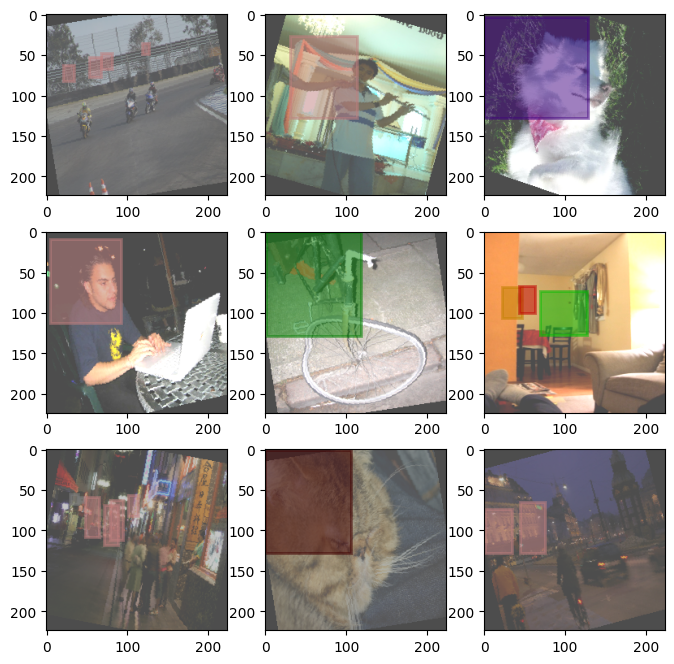

In [25]:
## Check a Batch:
########
import matplotlib.patches as patches
from PIL import Image


fig1, ax1 = plt.subplots(3, 3, figsize=(8,8))
ax1 = ax1.flatten()


index=0
for i in range(9):

    ax1[i].imshow(img[i].permute(1,2,0), alpha=.7)


    #Plot the boxes:
    #Based on our extraction
    W = H = 128

    for x1 in range(S):
        for y1 in range(S):
            if (is_object_grid[i+index,x1,y1]):
                #Get absolute xcenter, ycenter:
                x_center = (x_grid[i+index,x1,y1] + x1*cell_width)
                y_center = (y_grid[i+index,x1,y1] + y1*cell_width)

                width = w_grid[i+index,x1,y1]
                height = h_grid[i+index,x1,y1]

                xmin = x_center - width/2.
                ymin = y_center - height/2.


                color_index = int(class_grid[i+index,x1,y1])

                rectangle = patches.Rectangle((xmin*W, ymin*H), #bottom left
                                       (width)*W,   #width
                                       (height)*H,   #height
                                       facecolor=voc_cmap(color_index),
                                       edgecolor=voc_cmap(color_index),
                                       linewidth=2,
                                       alpha=.5)

                ax1[i].add_patch(rectangle)



#### Model Design

- Detect objects across a 7x7 grid: The model should yield a final output of shape 7x7x26
- For each gridcell there are 26 outputs: 4 coordinates (center x, center y, width, height) for a single bounding box, 1 objectness score, and 21 class scores (including a background class)
- Note that center x and y coordinates are relative to the gridcell, while height and width are relative to the image.

- Your model should consist of a CNN backbone (decide the details yourself), followed by a fully connected net that yields outputs that are reshaped to a final 7x7x26 shape. Alternatively, you can use a fully convolutional architecture.


In [ ]:
# model design

# pascal voc data -> 224 x 224

class Yolo_V0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
           # we have to go from 224 to 7  
           # each maxpool divides the dimension by half so 224/32 = 7 so 2^5
           # putting kernelsize2 and stride 2 divides the image in half while model learns from layers
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 112
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 56
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            # 28
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            # 14
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            
            # 7
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            
            # logit layer
            nn.Conv2d(in_channels=512, out_channels=26, kernel_size=1, stride=1, padding=0)
       ) 

    def forward(self, x):
        assert torch.isfinite(x).all(), "Non-finite values in model input"
        x = self.layers(x)
        x = torch.nan_to_num(x, nan=0.0, posinf=1e4, neginf=-1e4)
        # default pytorch (batch_size, 26, 7, 7)
        # yolo expects instead (batch_size, 7, 7, 26)
        x = x.permute(0,2,3,1)
        return x

In [27]:
# model instance
model = Yolo_V0()
model.layers

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU()
  (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (15): BatchNorm2d(256, eps=1e-05, momentum=0.

### Training

- get image, object prob, class score, x center, y center, width, height and loop over trainer loader
- pass image to model
- slice output from model to x y w h and objectness and class tensors
- calculate loss
    - sum all the mse losses of x y w h 
    - sum bg and obj pred mse loss 
    - ce loss of classes
    - sum all losses weight the 


- Every ground truth object should be assigned to a single gridcell based on center coordinates.

- You should have three basic loss terms:

1. Coordinate loss: Use MSE for center x and center y coordinates, and MSE for the square root of height and width. Only calculate a coordinate loss for gridcells that have an associated ground truth box. Scale coordinate loss by a factor of `5`.
2. Confidence loss: Use MSE on your objectness score vs. ground truth; weight cells that do not have a groun truth box by a factor of `0.5`.
3. Class loss: Use cross-entropy loss for object class; ignore the background class


i was encountering nan issue, where the mse loss was taking the square root of negaitve or zero values when i did w*is_obj.sqrt, since w contained negative predictions or zeros, i was getting NaN

so i added exp to kind of keep positive values slightly 

In [28]:
torch.exp?

Docstring:
exp(input, *, out=None) -> Tensor

Returns a new tensor with the exponential of the elements
of the input tensor :attr:`input`.

.. math::
    y_{i} = e^{x_{i}}

Args:
    input (Tensor): the input tensor.

Keyword args:
    out (Tensor, optional): the output tensor.

Example::

    >>> torch.exp(torch.tensor([0, math.log(2.)]))
    tensor([ 1.,  2.])
Type:      builtin_function_or_method


In [29]:
# device,optimizers, lossfn

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
device= "cuda" if torch.cuda.is_available() else "cpu"
mse_loss = nn.MSELoss(reduction='sum')
ce_loss = nn.CrossEntropyLoss(reduction='sum')
epochs = 100

model.to(device)




Yolo_V0(
  (layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 

In [ ]:
def train(epochs):
    model.train()
    for epoch in range(epochs):
        # We just keep one list for the total loss to keep it clean
        _coordinate_loss=[]
        _objectness_loss=[]
        _classification_loss=[]
        _total_loss=[]
        
        for img, is_obj, class_idx, x_gt, y_gt, w_gt, h_gt in train_loader:
            img = img.to(device)
            is_obj = is_obj.to(device)
            x_gt, y_gt, w_gt, h_gt = x_gt.to(device), y_gt.to(device), w_gt.to(device), h_gt.to(device)
            class_idx = class_idx.to(device).long()  
            
            # print(x_gt.shape, y_gt.shape, w_gt.shape, h_gt.shape)
            # print(x_gt, y_gt, w_gt, h_gt)

            assert not (x_gt.isnan().any() or y_gt.isnan().any() or w_gt.isnan().any() or h_gt.isnan().any()), "Nan found at 19!"
            
            optimizer.zero_grad()
            
            # For each gridcell there are 26 outputs that is 4 coordinates (center x, center y, width, height) for a single bounding box, 1 objectness score, and 21 class scores (including a background class)
            pred = model(img) # (Batch, 7, 7, 26)
            
            # print(pred.shape)
            # print(pred)
            
            assert not (pred.isnan().any()), "Nan found!"

            
            # we have to extract 0:3 indices for 4 coordinates, 4 for objectness score and 5:20 for class scores
            x, y = torch.sigmoid(pred[:,:,:,0]),torch.sigmoid(pred[:,:,:, 1]) # ... because we dont wanna change other parts of array dimension
            w, h = pred[:,:,:,2], pred[:,:,:, 3]
            w = torch.clamp(w, min=-10, max=10) # width height can be negative so adding euler's number exponent will keep positive things becaause we are perofrming non linear (exp) operations on w and h in future causing it to overflow or sqrt returning negative inputs
            h = torch.clamp(h, min=-10, max=10) 
            objectness = pred[:,:,:,4]
            class_ = pred[:,:,:,5:] 
            
            # print("p_x shape",x.shape)
            # print("is_obj shape",is_obj.shape)
            # print("p_y shape",y.shape)
            # print("w shape",w.shape)
            # print("h shape",h.shape)
            # print("w_gt shape",w_gt.shape)
            # print("h_gt shape",h_gt.shape)
            

            # We multiply by is_obj so it only counts for cells that have an object
            # p_x[0,3,4] * is_obj[0,3,4] = predicted_value * 0 = 0 or x_gt[0,3,4] * is_obj[0,3,4] = gt_value * 0 = 0 so the Loss contribution = 0 
            
            x_center_loss = mse_loss(x * is_obj, x_gt * is_obj)
            assert not (x_center_loss.isnan().any()), "Nan found!"
            
            
            y_center_loss = mse_loss(y * is_obj, y_gt * is_obj)
            assert not (y_center_loss.isnan().any()), "Nan found!"
            
            
            x_y_centered_loss = x_center_loss + y_center_loss
            assert not (x_y_centered_loss.isnan().any()), "Nan found!"
            
            
            # print((w * is_obj).sqrt().shape)
            # print((w_gt * is_obj).sqrt().shape)
            width_loss = mse_loss((w * is_obj).sqrt(), (w_gt * is_obj).sqrt())
            # print(width_loss)
            assert not (width_loss.isnan().any()), "Nan found!"
            
            height_loss = mse_loss((h * is_obj).sqrt(), (h_gt * is_obj).sqrt())
            assert not (height_loss.isnan().any()), "Nan found!"
            
            box_loss = width_loss + height_loss
            assert not (box_loss.isnan().any()), "Nan found!"
            
            

            # sqrt root for w and h so that model is critiqzed more heaivly on small boxes than on largeo nes  
            coordinate_loss =  x_y_centered_loss +  box_loss
            assert not (coordinate_loss.isnan().any()), "Nan found!"
            
            # we scale coordinate loss by 5 as mentioned
            coordinate_loss = coordinate_loss * 5
            
            # we weight 1.0 if object, 0.5 if background so that empty grid cells doesnt outweigh the training with noise since background is less imp than we do about the objects
            conf_diff = (objectness - is_obj)**2 # subtract the isobj array from this so we dont penalize for background
            weights = (is_obj * 1.0) + ((1 - is_obj) * 0.5) # different weights for object vs background cells, we do 0.5 If we weighted them equally, background loss would dominate

            objectiveness_loss = (conf_diff * weights).sum()
            # 0.01 * 1.0 = 0.01 full penalty for missed detection
            #  0.64 * 0.5 = 0.32 reduced penalty for background false positive

            assert not (objectiveness_loss.isnan().any()), "Nan found!"

            # We reshape to (Batch*7*7, 21) for CrossEntropy
            # We only calculate this where is_obj == 1 since class loss for only where object exists 
            class_loss = F.cross_entropy(class_.reshape(-1, 21), class_idx.reshape(-1), reduction='none') * is_obj.reshape(-1)
            
            assert not (class_loss.isnan().any()), "Nan found!"

            class_loss = class_loss.sum()

            total_loss = coordinate_loss + objectiveness_loss + class_loss
            total_loss.backward()
            optimizer.step()
            
            _total_loss.append(total_loss.item())
            _coordinate_loss.append(coordinate_loss.item())
            _objectness_loss.append(objectiveness_loss.item())
            _classification_loss.append(class_loss.item())
        
        

        print(f"Epoch {epoch}, coordinate loss : {sum(_coordinate_loss) / len(_coordinate_loss):.4f} | objectness_loss: {sum(_objectness_loss) / len(_objectness_loss):.4f} | classification_loss: {sum(_classification_loss) / len(_classification_loss):.4f} | total_loss: {sum(_total_loss) / len(_total_loss):.4f}")

            
        
        
train(epochs=epochs)

Epoch 0, coordinate loss : 439.7651 | objectness_loss: 68.3473 | classification_loss: 208.0850 | total_loss: 716.1974
Epoch 1, coordinate loss : 439.2900 | objectness_loss: 68.4452 | classification_loss: 208.3830 | total_loss: 716.1182
Epoch 2, coordinate loss : 439.6461 | objectness_loss: 68.4499 | classification_loss: 208.3972 | total_loss: 716.4932
Epoch 3, coordinate loss : 438.7205 | objectness_loss: 68.2354 | classification_loss: 207.7443 | total_loss: 714.7002
Epoch 4, coordinate loss : 439.1851 | objectness_loss: 68.3706 | classification_loss: 208.1559 | total_loss: 715.7116


### Eval


- Implement the non-max suppression (NMS) algorithm for inference, using reasonable objectness and IoU thresholds.
- Visualize the results of your object detection model on some example inputs

In [ ]:
# eval loop

model.eval()
all_results = [] # img, f_boxes, f_classes

with torch.no_grad():
    for img, _ in valid_loader:
        img = img.to(device)
        pred = model(img) # Batch, 7, 7, 26)
        
        for i in range(len(img)):
            # reshape to 49,26 since 49 = 7x7 grid cells where each cell will contain 26 pred classes
            boxes = pred[i].reshape(-1, 26)
            # top left corner 
            x1 = boxes[:, 0] - boxes[:, 2] / 2
            y1 = boxes[:, 1] - boxes[:, 3] / 2
            # bottom right corner
            x2 = boxes[:, 0] + boxes[:, 2] / 2
            y2 = boxes[:, 1] + boxes[:, 3] / 2
            boxes_corners = torch.stack([x1, y1, x2, y2], dim=1)
            
            scores = boxes[:, 4] # single value per box
            classes = torch.argmax(boxes[:, 5:], dim=-1) # most likely greedy
            
            keep = scores > 0.5  # our thresold for 
            # non max suppression for removing overlapping boxes with provided IoU
            nms_idx = torchvision.ops.nms(boxes_corners[keep], scores[keep], iou_threshold=0.3)
            
            all_results.append((img[i], boxes_corners[keep][nms_idx], classes[keep][nms_idx]))

NameError: name 'model' is not defined

In [ ]:
# plot images
for img, f_boxes, f_classes in all_results:
    fig, ax = plt.subplots(1)
    # 3, 128,128
    ax.imshow(img.permute(1, 2, 0))
    
    # 128,128,3
    for b in range(len(f_boxes)):
        box = f_boxes[b]
        # we multiply by 128 since their prenormalized so we get pixel values at teh end
        x, y, x2, y2 = box[0] * 128, box[1] * 128, box[2] * 128, box[3] * 128 
        w, h = x2 - x, y2 - y # width and height of the box detection
        
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none') # create rectange with the position of where the rectangle to show for detection and how big to show
        ax.add_patch(rect)
        
    plt.show()

In [ ]:
torch.save(model.state_dict(), "yolov0.pt")